## Rozpoznawanie stanu flow na podstawie sygnałów fizjologicznych

Celem projektu jest stworzenie modelu zdolnego do klasyfikacji występowania stanu flow u człowieka na podstawie sygnałów fizjologicznych.

## Zbiór danych

Do wytrenowania modelu użyty został zbiór danych PhySF: https://osf.io/hgj6p/overview?view_only=1a23513a3ff24eae9afb47bcaba9f4f2

Zbiór powstał w ramach badania na 25 uczestnikach, dla każdej próbki sygnału oznaczono występowanie stanu flow.

Struktura danych:

* BVP – sygnał objętości krwi (Blood Volume Pulse), używany do analizy pracy serca i pochodnych (np. HR)
* EDA – aktywność elektrodermalna (przewodnictwo skóry), wskaźnik pobudzenia emocjonalnego / stresu
* Tmp – temperatura skóry
* IBI – odstępy między uderzeniami serca (Inter-Beat Interval)
* HR – tętno (Heart Rate), liczba uderzeń serca na minutę
* Resp – sygnał oddechu (częstość / rytm oddychania)
* EOG – elektrookulogram, aktywność mięśni oka (ruchy gałek ocznych, mruganie)
* ECG – elektrokardiogram, elektryczna aktywność serca
* EMG – elektromiogram, aktywność mięśni

Kanały EEG (aktywność mózgu):

* EEG.AF3, EEG.AF4 – przednia część kory (obszary czołowe, uwaga, kontrola poznawcza)
* EEG.F3, EEG.F4, EEG.F7, EEG.F8 – płaty czołowe (decyzje, koncentracja, funkcje wykonawcze)
* EEG.FC5, EEG.FC6 – obszary czołowo-centralne (integracja ruchu i poznania)
* EEG.T7, EEG.T8 – płaty skroniowe (przetwarzanie słuchowe, emocje)
* EEG.P7, EEG.P8 – płaty ciemieniowe (integracja sensoryczna, uwaga przestrzenna)
* EEG.O1, EEG.O2 – płaty potyliczne (przetwarzanie wzrokowe)

### Wczytywanie danych

In [1]:
import pandas as pd
import glob
import os

files = glob.glob("data/*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    
    # label z nazwy pliku
    if "no_flow" in f:
        df["label"] = 0
    else:
        df["label"] = 1
        
    # subject id
    df["subject"] = os.path.basename(f).split('_')[0]
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

In [6]:
data.head()

,Unnamed: 0,BVP,EDA,Tmp,IBI,HR,Resp,EOG,ECG,EMG,...,EEG.O1,EEG.O2,EEG.P8,EEG.T8,EEG.FC6,EEG.F4,EEG.F8,EEG.AF4,label,subject
0,0,11.981396,35.327718,35.775000,0.820351,73.188750,-0.040805,13.243733,-0.018476,-0.000608,...,4331.282227,4335.769043,4314.230957,4276.794922,4462.307617,4448.333496,4370.897461,4434.743652,1,s10
1,1,11.564880,35.326907,35.775039,0.820342,73.189575,-0.040829,13.234647,-0.018342,-0.000606,...,4337.948730,4343.846191,4321.538574,4275.769043,4458.974121,4456.666504,4358.974121,4435.897461,1,s10
2,2,11.148378,35.326097,35.775078,0.820333,73.190400,-0.040854,13.225562,-0.018209,-0.000604,...,4337.307617,4347.051270,4326.794922,4283.461426,4467.051270,4466.410156,4372.179688,4442.436035,1,s10
3,3,10.731863,35.325287,35.775117,0.820324,73.191225,-0.040878,13.216477,-0.018076,-0.000602,...,4334.230957,4352.179688,4335.512695,4295.128418,4483.717773,4476.410156,4404.230957,4456.794922,1,s10
4,4,10.315361,35.324477,35.775156,0.820316,73.192050,-0.040903,13.207391,-0.017942,-0.000599,...,4333.333496,4359.871582,4344.102539,4295.897461,4480.000000,4476.410156,4406.666504,4456.282227,1,s10


In [9]:
data["label"].value_counts()

label
0    3999666
1    2978229
Name: count, dtype: int64

## Wstępna analiza danych

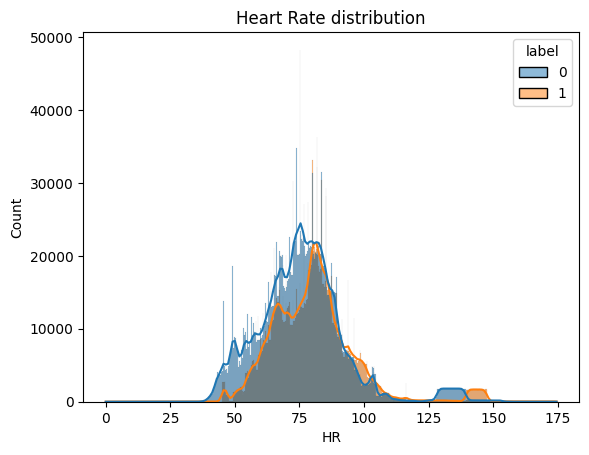

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=data, x="HR", hue="label", kde=True)
plt.title("Heart Rate distribution")
plt.show()

Widać że flow przesuwa rozkład HR

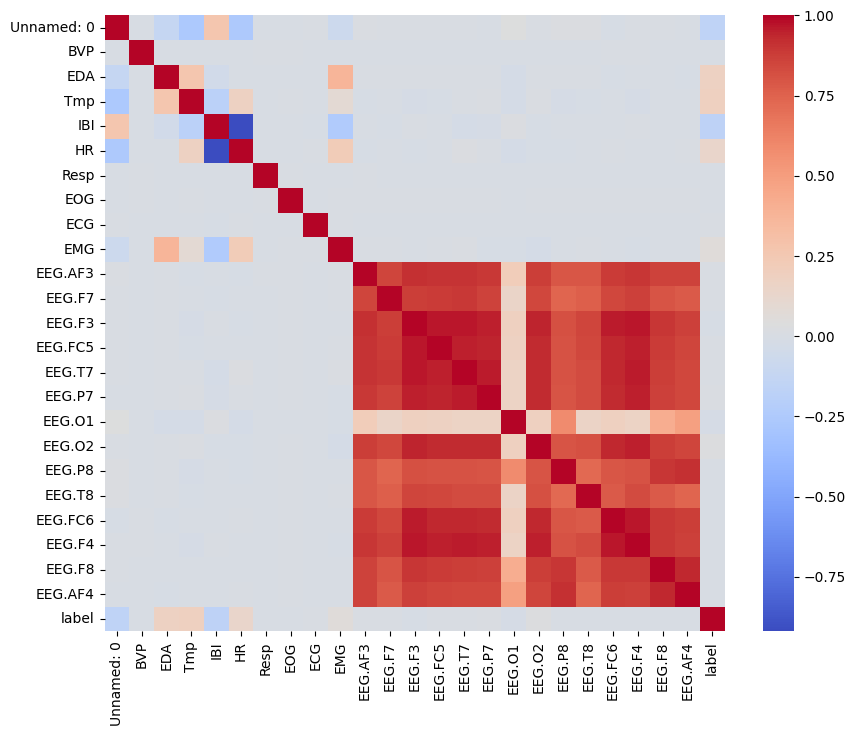

In [14]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

## Funkcja okna

* Częstotliwość próbkowania: 128 Hz
* Rozmiar okna: 10 sekund
* Krok: 50% okna (5 sekund)

In [2]:
fs = 128
window_size = 10 * fs
step_size = 5 * fs

In [3]:
import numpy as np

def create_windows(df, window_size, step_size, feature_cols):
    X = []
    y = []

    for start in range(0, len(df) - window_size, step_size):
        window = df.iloc[start:start + window_size]
        
        features = window[feature_cols]
        
        # label = majority vote
        label = window["label"].mode()[0]
        
        X.append(features)
        y.append(label)

    return X, y

## Pipeline treningowy

1. Najpierw obliczana jest globalna średnia i odchylenie standardowe dla wybranych cech (HR, IBI, Resp, EDA, Tmp, BVP). Następnie dane każdego uczestnika są skalowane (z-score) względem tych globalnych statystyk.

2. Wyznaczenie baseline’u dla uczestnika
    * Dla każdego subject liczona jest średnia wartość sygnałów (baseline), która później służy jako punkt odniesienia przy ekstrakcji cech.

3. Segmentacja na okna czasowe
    * Dane są dzielone na przesuwające się okna (window_size, step_size).
    * Każde okno otrzymuje etykietę (label), tworząc zbiór próbek.

4. Budowa wejścia do modelu
    * Każda próbka to para:
        * (okno sygnału, baseline uczestnika)
    * Dodatkowo tworzona jest lista groups, aby śledzić przynależność do uczestnika (do walidacji grupowej).

5. Ekstrakcja cech (FeatureExtractor)
    * Dla każdej cechy w oknie obliczane są statystyki:
        * średnia, odchylenie standardowe, minimum, maksimum
        * statystyki różnic (np.diff): średnia i odchylenie
        * trend (nachylenie regresji liniowej)
        * różnica względem baseline’u
    * Wszystkie te wartości są łączone w jeden wektor cech dla okna.

6. Pipeline modelowy
    * Pipeline składa się z trzech etapów:
    * ekstrakcja cech (FeatureExtractor)
    * standaryzacja cech (StandardScaler)
    * klasyfikacja (XGBClassifier – gradient boosting)

7. Walidacja krzyżowa z grupami
    * Używany jest GroupKFold, który zapewnia, że dane jednego uczestnika nie trafiają jednocześnie do treningu i testu

8. Ewaluacja modelu
    * Model oceniany jest przy użyciu:
        * accuracy
        * F1-score
    * Wyniki są uśredniane po 5 foldach i raportowane jako średnia ± odchylenie standardowe.

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from scipy.stats import linregress

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        feats = []
        for window, baseline in X:
            if hasattr(window, 'columns'):
                cols = window.columns
                get_col = lambda i: window[i].values
            else:
                cols = range(window.shape[1])
                get_col = lambda i: window[:, i]
                
            window_feats = []
            for idx, i in enumerate(cols):
                x = get_col(i)
                diff = np.diff(x)
                trend_slope, _, _, _, _ = linregress(np.arange(len(x)), x)
                
                mean_x = np.mean(x)
                std_x = np.std(x)
                min_x = np.min(x)
                max_x = np.max(x)
                mean_diff = np.mean(diff)
                std_diff = np.std(diff)
                
                if hasattr(window, 'columns'):
                    delta_baseline = mean_x - baseline[i]
                else:
                    delta_baseline = mean_x - baseline[idx]
                    
                window_feats.extend([
                    mean_x,
                    std_x,
                    min_x,
                    max_x,
                    mean_diff,
                    std_diff,
                    trend_slope,
                    delta_baseline,
                    # TODO: mediana, percentyle, kurtoz
                ])
            feats.append(window_feats)
        return np.array(feats)

X_windows = []
y_labels = []
groups = []

feature_cols = ['HR', 'IBI', 'Resp', 'EDA', 'Tmp', 'BVP']
# TODO: ocenić które cehy sygnału mają największy wkład

global_mean = data[feature_cols].mean()
global_std = data[feature_cols].std()

for subject_id, df_sub in data.groupby("subject"):
    df_sub_scaled = df_sub.copy()
    df_sub_scaled[feature_cols] = (df_sub[feature_cols] - global_mean) / global_std
    
    baseline = df_sub[feature_cols].mean().to_dict()
    
    windows, labels = create_windows(df_sub_scaled, window_size, step_size, feature_cols)
    
    X_windows.extend([(w, baseline) for w in windows])
    y_labels.extend(labels)
    groups.extend([subject_id]*len(labels))

pipeline = Pipeline([
    ('feat', FeatureExtractor()),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

gkf = GroupKFold(n_splits=5)
acc_scores = cross_val_score(pipeline, X_windows, y_labels, groups=groups, cv=gkf, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_windows, y_labels, groups=groups, cv=gkf, scoring='f1_macro')

print("=== RESULTS ===")
print(f"Mean Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Mean F1-score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

=== RESULTS ===
Mean Accuracy: 0.5963 ± 0.0908
Mean F1-score: 0.5781 ± 0.0901


In [6]:
from collections import Counter

print("Global:", Counter(y_labels))

import pandas as pd
df = pd.DataFrame({'y': y_labels, 'g': groups})
df.groupby('g')['y'].value_counts()

Global: Counter({np.int64(0): 6224, np.int64(1): 4642})


g    y
s1   0    178
     1    158
s10  1    276
     0     97
s11  0    577
s12  0    348
     1     42
s13  1    237
     0    125
s14  0    229
     1    211
s15  0    241
     1    123
s16  1    278
     0    246
s17  0    376
     1    123
s18  1    279
     0    207
s19  1    321
     0     45
s2   1    190
     0    141
s20  0    757
     1     63
s21  0    223
     1    169
s22  1    285
     0    206
s23  1    471
     0     47
s24  0    493
s25  0    365
     1     49
s3   1    217
     0    204
s4   1    390
     0    136
s5   1    518
     0     67
s6   0    423
     1     50
s7   1     92
s8   0    473
s9   1    100
     0     20
Name: count, dtype: int64

In [8]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import cross_validate

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_labels
)

scores = cross_validate(
    pipeline,
    X_windows,
    y_labels,
    groups=groups,
    cv=gkf,
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1_macro'
    },
    params={
        'clf__sample_weight': sample_weights
    }
)

print("=== RESULTS ===")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.4f} ± {np.std(scores['test_accuracy']):.4f}")
print(f"Mean F1-score: {np.mean(scores['test_f1']):.4f} ± {np.std(scores['test_f1']):.4f}")

=== RESULTS ===
Mean Accuracy: 0.6148 ± 0.0837
Mean F1-score: 0.5979 ± 0.0898


In [10]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedGroupKFold

gkf = StratifiedGroupKFold(n_splits=5)

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_labels
)

scores = cross_validate(
    pipeline,
    X_windows,
    y_labels,
    groups=groups,
    cv=gkf,
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1_macro'
    },
    params={
        'clf__sample_weight': sample_weights
    }
)

print("=== RESULTS ===")
print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.4f} ± {np.std(scores['test_accuracy']):.4f}")
print(f"Mean F1-score: {np.mean(scores['test_f1']):.4f} ± {np.std(scores['test_f1']):.4f}")

=== RESULTS ===
Mean Accuracy: 0.6226 ± 0.0533
Mean F1-score: 0.6061 ± 0.0602


### TODO:

- lepszy split (leave one subject out)
- inne modele (liniowe (lepsze dla HR), tree, adaboost, randomforest, SVM [różne jądra, wielomianowe, gaussa, wlasna funkcja jadra], heurystyki i algorytmy rojowe)
- nowe cechy, zmienność tętna w czasie, wytyczne HRV reccomendations 1996 (cechy opisane w artykule)